<a href="https://colab.research.google.com/github/karolinehernes1/Jupyter-notebooks/blob/main/KAROLINE_HERNES_Homework3_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Karoline Nagelhus Hernes

## Part 1.1

#### 1.1 Load data:

Load the California Housing dataset from scikit-learn.
Load features/target; print shape and first 5 rows.
Train/validation/test split (e.g., 60/20/20). Use random_state=42.

In [ ]:
from sklearn.datasets import fetch_california_housing

california_housing = fetch_california_housing(as_frame =True)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load features (X) and target (y)
X = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
y = pd.Series(california_housing.target, name='MedHouseVal')

In [ ]:
# Print shapes
print(f'Shape of features (X): {X.shape}')
print(f'Shape of target (y): {y.shape}')

# Print first 5 rows of features
print('\nFirst 5 rows of features (X):')
display(X.head())

Shape of features (X): (20640, 8)
Shape of target (y): (20640,)

First 5 rows of features (X):


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
# Split data into training (60%), validation (20%), and test (20%) sets

# First, split into training + validation (80%) and test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Then, split training + validation (X_train_val, y_train_val) into training (60%) and validation (20%)
# Since X_train_val is 80% of the original data, 25% of X_train_val will be 20% of the original data.
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

print(f'\nShape of X_train: {X_train.shape}')
print(f'Shape of X_val: {X_val.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_val: {y_val.shape}')
print(f'Shape of y_test: {y_test.shape}')


Shape of X_train: (12384, 8)
Shape of X_val: (4128, 8)
Shape of X_test: (4128, 8)
Shape of y_train: (12384,)
Shape of y_val: (4128,)
Shape of y_test: (4128,)


#### 1.2. Create 2 models, and compare RMSE on the validation set.
Baseline model: for every input, the model will always predict y to be the mean of y_train
Linear Regression model

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Baseline Model: Predict the mean of y_train
y_train_mean = y_train.mean()
baseline_predictions = [y_train_mean] * len(y_val)

# Calculate RMSE for the baseline model
rmse_baseline = mean_squared_error(
    y_val, baseline_predictions
) ** 0.5

print("Baseline RMSE:", rmse_baseline)


Baseline RMSE: 1.171902614670744


In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the validation set
y_pred_linear = linear_model.predict(X_val)

# Calculate RMSE for the Linear Regression model
rmse_linear = np.sqrt(mean_squared_error(y_val, y_pred_linear))

print(f'Linear Regression Model RMSE on Validation Set: {rmse_linear:.4f}')

Linear Regression Model RMSE on Validation Set: 0.7278


In [ ]:
### Model Comparison
print('--- RMSE Comparison on Validation Set ---')
print(f'Baseline Model RMSE:     {rmse_baseline:.4f}')
print(f'Linear Regression Model RMSE: {rmse_linear:.4f}')

if rmse_linear < rmse_baseline:
    print(f'The Linear Regression model performed better than the baseline by {rmse_baseline - rmse_linear:.4f}.')
else:
    print('The baseline model performed better or equal to the Linear Regression model.')

--- RMSE Comparison on Validation Set ---
Baseline Model RMSE:     1.1719
Linear Regression Model RMSE: 0.7278
The Linear Regression model performed better than the baseline by 0.4441.


#### 1.3. Create a Visualization with the following guidelines:
- Uses only MedInc as the feature (X) and MedHouseVal as the target (y).
- Selects about 12 evenly spaced validation points to plot. Creates a plot that shows:
- the regression line (dashed)
- observed validation values as solid points   
- predicted values as hollow points   
- dotted vertical lines for residuals
- Limit the x-axis and y-axis to the real min and max of X and y.

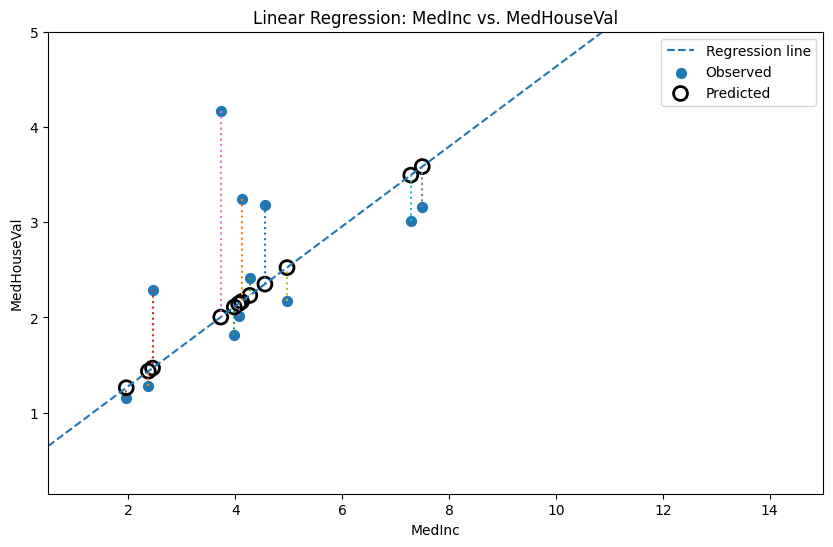

In [ ]:
import matplotlib.pyplot as plt

# Use only MedInc as the feature
X_income = X[["MedInc"]]

# Use MedHouseVal as the target
y_house = y

# Split the data into training and temporary data
X_income_train, X_income_temp, y_house_train, y_house_temp = train_test_split(
    X_income, y_house, test_size=0.40, random_state=42
)

# Split temporary data into validation and test
X_income_val, X_income_test, y_house_val, y_house_test = train_test_split(
    X_income_temp, y_house_temp, test_size=0.50, random_state=42
)

# Create and train a new linear regression model
income_model = LinearRegression()
income_model.fit(X_income_train, y_house_train)

# Make predictions on validation data
income_predictions = income_model.predict(X_income_val)

# Select about 12 evenly spaced validation points
indices = range(0, len(X_income_val), len(X_income_val) // 12)

x_points = X_income_val.iloc[list(indices)]["MedInc"]
y_observed = y_house_val.iloc[list(indices)]
y_predicted = income_predictions[list(indices)]

# Create values for the regression line
x_line = X_income["MedInc"].sort_values()
y_line = income_model.predict(x_line.to_frame())

# Create the plot
plt.figure(figsize=(10, 6))

# Regression line
plt.plot(
    x_line,
    y_line,
    linestyle="--",
    label="Regression line"
)

# Observed values: solid points
plt.scatter(
    x_points,
    y_observed,
    label="Observed",
    marker="o",
    s=50
)

# Residual lines
for x, observed, predicted in zip(
    x_points, y_observed, y_predicted
):
    plt.plot(
        [x, x],
        [observed, predicted],
        linestyle=":"
    )

# Predicted values: hollow points
# Plot these LAST so they are visible
plt.scatter(
    x_points,
    y_predicted,
    label="Predicted",
    marker="o",
    facecolors="none",
    edgecolors="black",
    s=100,
    linewidths=2
)

# Labels
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.title("Linear Regression: MedInc vs. MedHouseVal")

# Set axes to the real minimum and maximum
plt.xlim(X_income["MedInc"].min(), X_income["MedInc"].max())
plt.ylim(y_house.min(), y_house.max())

plt.legend()
plt.show()

#### 1.4. Report RMSE and R² on the validation set.
Prompt: “Please calculate RMSE, then explain R2 and calculate it. Please keep the code super simple and explain all the steps.”


In [ ]:
# Import R2
from sklearn.metrics import r2_score

# Calculate RMSE
rmse = mean_squared_error(
    y_house_val, income_predictions
) ** 0.5

# Calculate R2
r2 = r2_score(
    y_house_val, income_predictions
)

# Print the results
print("Validation RMSE:", rmse)
print("Validation R²:", r2)

Validation RMSE: 0.845281024616178
Validation R²: 0.4526316215409414


## Part 1.2

In [ ]:
# Import libraries
import tensorflow as tf

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Scale pixel values from 0-255 to 0-1
x_train = x_train / 255.0
x_test = x_test / 255.0

# Use part of the training data as validation data
x_val = x_train[-10000:]
y_val = y_train[-10000:]

x_train = x_train[:-10000]
y_train = y_train[:-10000]

print("Training data:", x_train.shape)
print("Validation data:", x_val.shape)
print("Test data:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data: (50000, 28, 28)
Validation data: (10000, 28, 28)
Test data: (10000, 28, 28)


In [ ]:
# Create the model
model_a = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Tell the model how to train
model_a.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the model
history_a = model_a.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_val, y_val)
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9181 - loss: 0.2858 - val_accuracy: 0.9579 - val_loss: 0.1543
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9614 - loss: 0.1304 - val_accuracy: 0.9695 - val_loss: 0.1115
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9749 - loss: 0.0864 - val_accuracy: 0.9692 - val_loss: 0.0994
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9798 - loss: 0.0648 - val_accuracy: 0.9760 - val_loss: 0.0816
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9848 - loss: 0.0490 - val_accuracy: 0.9733 - val_loss: 0.0871


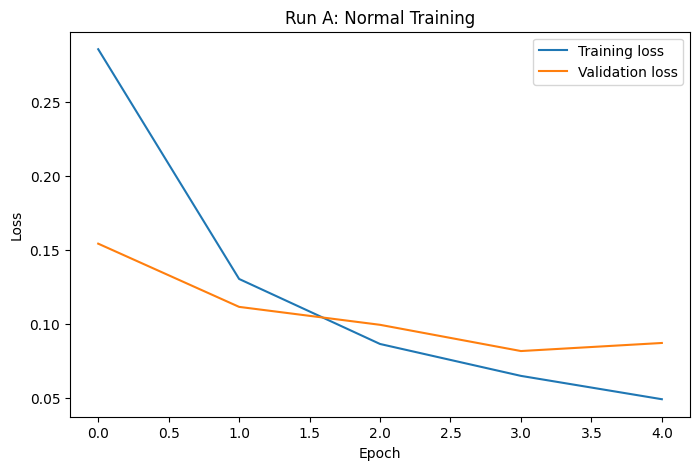

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history_a.history["loss"], label="Training loss")
plt.plot(history_a.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Run A: Normal Training")
plt.legend()
plt.show()

In [ ]:
# Use only a tiny training set
x_train_small = x_train[:1000]
y_train_small = y_train[:1000]

# Create a new model
model_b = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Compile the model
model_b.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train for many epochs
history_b = model_b.fit(
    x_train_small,
    y_train_small,
    epochs=50,
    validation_data=(x_val, y_val)
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.6230 - loss: 1.4734 - val_accuracy: 0.8017 - val_loss: 0.8545
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8530 - loss: 0.6070 - val_accuracy: 0.8471 - val_loss: 0.5544
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9040 - loss: 0.3970 - val_accuracy: 0.8737 - val_loss: 0.4545
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9300 - loss: 0.3059 - val_accuracy: 0.8738 - val_loss: 0.4335
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9430 - loss: 0.2434 - val_accuracy: 0.8743 - val_loss: 0.4116
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9580 - loss: 0.2012 - val_accuracy: 0.8830 - val_loss: 0.3987
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9650 - loss: 0.1663 - val_accuracy: 0.8822 - val_loss: 0.3922
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9760 - loss: 0.1351 - val_accuracy: 0.8885 - v

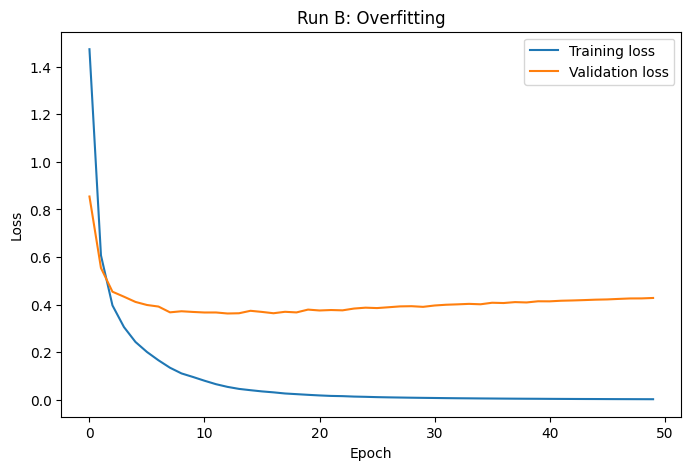

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history_b.history["loss"], label="Training loss")
plt.plot(history_b.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Run B: Overfitting")
plt.legend()
plt.show()

## Part 1.3

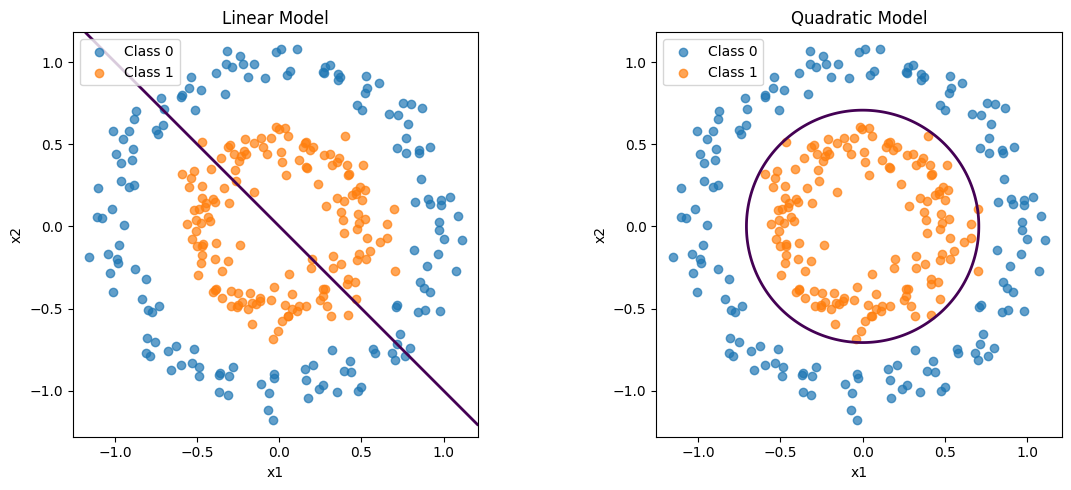

Linear model:
score = 1.0*x1 + 1.0*x2 + 0.0

Quadratic model:
score = 0.0*x1 + 0.0*x2 + 1.0*x1² + 0.0*x1*x2 + 1.0*x2² + -0.5


In [ ]:
# Import dataset
from sklearn.datasets import make_circles


# ============================================================
# 1. HAND-SET CONSTANTS
# ============================================================
# These are the weights that the models will use.
# We are NOT training the models.
#
# Linear model:
#     score = w1*x1 + w2*x2 + bias
#
# Quadratic model:
#     score = w1*x1 + w2*x2 + w3*x1^2 + w4*x1*x2 + w5*x2^2 + bias
#
# For the circles data, the quadratic model can use x1^2 + x2^2
# to recognize the circular shape.

WEIGHTS_LINEAR = np.array([1.0, 1.0])
BIAS_LINEAR = 0.0

# Order of these weights:
# [x1, x2, x1^2, x1*x2, x2^2]
WEIGHTS_QUADRATIC = np.array([0.0, 0.0, 1.0, 0.0, 1.0])
BIAS_QUADRATIC = -0.5


# ============================================================
# 2. FEATURE FUNCTIONS
# ============================================================

def make_features_linear(X):
    """
    Keep the original two features:
    [x1, x2]
    """
    x1 = X[:, 0]
    x2 = X[:, 1]

    return np.column_stack([x1, x2])


def make_features_quadratic(X):
    """
    Add squared and interaction features:
    [x1, x2, x1^2, x1*x2, x2^2]

    These extra features allow the model to create
    a curved/nonlinear decision boundary in the original
    x1-x2 space.
    """
    x1 = X[:, 0]
    x2 = X[:, 1]

    return np.column_stack([
        x1,
        x2,
        x1**2,
        x1*x2,
        x2**2
    ])


# ============================================================
# 3. FUNCTION TO PLOT A MODEL USING HAND-SET WEIGHTS
# ============================================================

def plot_with_weights(ax, X, y, w, b, make_features, title):
    """
    Plot the data and the decision boundary for a model.

    w = hand-set weights
    b = hand-set bias
    make_features = function that creates the model's features

    The model calculates:

        score = X_features @ weights + bias

    We classify:
        score >= 0  -> class 1
        score < 0   -> class 0
    """

    # Create the features that this particular model uses
    features = make_features(X)

    # Calculate the model's score for every data point
    scores = features @ w + b

    # Turn scores into predictions
    predictions = (scores >= 0).astype(int)

    # Plot the two classes of observed data
    ax.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        label="Class 0",
        alpha=0.7
    )

    ax.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        label="Class 1",
        alpha=0.7
    )

    # --------------------------------------------------------
    # Create a grid of x1 and x2 values.
    # We use this grid to visualize where the model
    # changes from class 0 to class 1.
    # --------------------------------------------------------

    x1_min, x1_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    x2_min, x2_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

    x1_grid = np.linspace(x1_min, x1_max, 300)
    x2_grid = np.linspace(x2_min, x2_max, 300)

    # Make a 2D grid
    xx1, xx2 = np.meshgrid(x1_grid, x2_grid)

    # Turn the grid into the same format as X
    grid = np.column_stack([
        xx1.ravel(),
        xx2.ravel()
    ])

    # Create the appropriate features for the grid
    grid_features = make_features(grid)

    # Calculate the model score across the entire grid
    grid_scores = grid_features @ w + b

    # Put the scores back into the shape of the grid
    grid_scores = grid_scores.reshape(xx1.shape)

    # Draw the decision boundary where score = 0
    ax.contour(
        xx1,
        xx2,
        grid_scores,
        levels=[0],
        linewidths=2
    )

    # Add title and labels
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

    # Make the x and y axes use the same scale
    # so that circles actually look like circles.
    ax.set_aspect("equal", adjustable="box")

    ax.legend()


# ============================================================
# 4. CREATE THE DATA
# ============================================================
# make_circles creates two classes:
#   - one circle inside another circle
#   - some noise is added so the points are not perfectly clean
#
# n_samples = total number of points
# factor controls the size of the inner circle
# noise adds randomness to the points

X, y = make_circles(
    n_samples=300,
    factor=0.5,
    noise=0.08,
    random_state=42
)


# ============================================================
# 5. MAKE THE TWO SIDE-BY-SIDE PLOTS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# Linear model
# -------------------------
plot_with_weights(
    axes[0],
    X,
    y,
    WEIGHTS_LINEAR,
    BIAS_LINEAR,
    make_features_linear,
    "Linear Model"
)

# -------------------------
# Quadratic model
# -------------------------
plot_with_weights(
    axes[1],
    X,
    y,
    WEIGHTS_QUADRATIC,
    BIAS_QUADRATIC,
    make_features_quadratic,
    "Quadratic Model"
)

plt.tight_layout()
plt.show()


# ============================================================
# 6. PRINT THE FORMULAS
# ============================================================
# Print the formulas so we can clearly see what each model is
# calculating.

print("Linear model:")
print(
    f"score = {WEIGHTS_LINEAR[0]}*x1 "
    f"+ {WEIGHTS_LINEAR[1]}*x2 "
    f"+ {BIAS_LINEAR}"
)

print()

print("Quadratic model:")
print(
    f"score = {WEIGHTS_QUADRATIC[0]}*x1 "
    f"+ {WEIGHTS_QUADRATIC[1]}*x2 "
    f"+ {WEIGHTS_QUADRATIC[2]}*x1² "
    f"+ {WEIGHTS_QUADRATIC[3]}*x1*x2 "
    f"+ {WEIGHTS_QUADRATIC[4]}*x2² "
    f"+ {BIAS_QUADRATIC}"
)

## Part 1.4 (Bonus)

### Gradient Descent Demo

Gradient descent is a way for a model to improve its predictions.
It repeatedly:
1. Makes a prediction.
2. Calculates the loss.
3. Calculates the gradient, which tells us which direction to change the weight.
4. Updates the weight.

We will use the very simple model: prediction = weight * x.


The learning rate controls how big each update is.
We will compare:
- A good learning rate: small enough to move toward the answer.
- A learning rate that is too big: takes steps that are too large and
  can make the loss get bigger instead of smaller.

In [ ]:
# Very simple data
x = 1
y = 2

# Start with a bad guess
weight = 0.0

# Make a prediction
prediction = weight * x

# Calculate the loss
loss = (prediction - y) ** 2

# Calculate the gradient
gradient = 2 * (prediction - y) * x

# Try a good learning rate
learning_rate = 0.1

# Update the weight
weight = weight - learning_rate * gradient

print("Prediction:", prediction)
print("Loss:", loss)
print("Gradient:", gradient)
print("New weight:", weight)

Prediction: 0.0
Loss: 4.0
Gradient: -4.0
New weight: 0.4


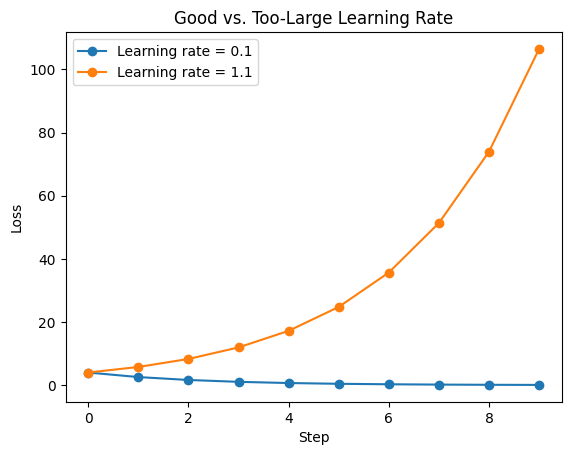

In [ ]:
# We will compare a good learning rate with one that is too big
learning_rates = [0.1, 1.1]

for learning_rate in learning_rates:

    # Start with the same weight each time
    weight = 0.0
    losses = []

    # Repeat gradient descent 10 times
    for step in range(10):

        # Make a prediction
        prediction = weight * x

        # Calculate the loss
        loss = (prediction - y) ** 2

        # Calculate the gradient
        gradient = 2 * (prediction - y) * x

        # Update the weight
        weight = weight - learning_rate * gradient

        # Save the loss
        losses.append(loss)

    # Plot the loss
    plt.plot(
        losses,
        marker="o",
        label="Learning rate = " + str(learning_rate)
    )

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Good vs. Too-Large Learning Rate")
plt.legend()
plt.show()

## Part 2 in google document

## Part 3 Quick MNIST demos in Keras/TensorFlow/Pytorch

### TensorFlow/Keras

In [ ]:
# Quick MNIST demo using Keras/Tensorflow

# Import TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras

# 1. Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# 2. Scale pixel values from 0-255 to 0-1
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. Create a simple neural network
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

# 4. Tell Keras how to train the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 5. Train the model
model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=64
)

# 6. Test the model on images it has not seen during training
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test accuracy:", test_accuracy)

Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9166 - loss: 0.2983
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9605 - loss: 0.1362
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9717 - loss: 0.0964
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9721 - loss: 0.0935
Test accuracy: 0.972100019454956


### Pytorch

In [ ]:
# Quick MNIST demo using PyTorch

# Import PyTorch
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

# 1. Load the MNIST dataset
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

# 2. Put the data into batches
train_loader = DataLoader(training_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

# 3. Create a simple neural network
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

# 4. Choose the loss function and optimizer
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

# 5. Train the model
for epoch in range(3):

    for images, labels in train_loader:

        # Make predictions
        predictions = model(images)

        # Calculate the loss
        loss = loss_function(predictions, labels)

        # Calculate gradients
        optimizer.zero_grad()
        loss.backward()

        # Update the model's weights
        optimizer.step()

# 6. Test the model
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        predictions = model(images)

        # Get the predicted digit
        predicted_digits = predictions.argmax(dim=1)

        total += labels.size(0)
        correct += (predicted_digits == labels).sum().item()

accuracy = correct / total

print("Test accuracy:", accuracy)

Test accuracy: 0.9699


## Part 4 in google document